In [2]:
#Cell Phone Price Range Prediction

## Problem Statement
Bob has started a mobile company and wants to compete with big brands. 
He collected mobile phone data containing specifications like RAM, battery power, 
camera etc. The objective is to analyze the dataset and build a machine learning 
model that predicts the price range of a mobile phone.

Price ranges:
0 → Low Cost
1 → Medium Cost
2 → High Cost
3 → Very High Cost

SyntaxError: invalid character '→' (U+2192) (3668837725.py, line 10)

In [5]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Loading the data set 
data = pd.read_csv("mobile_price.csv")
# Doing basic checks of the dataset
data.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [7]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [8]:
data.describe()


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [9]:
data.shape

(2000, 21)

In [10]:
data.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

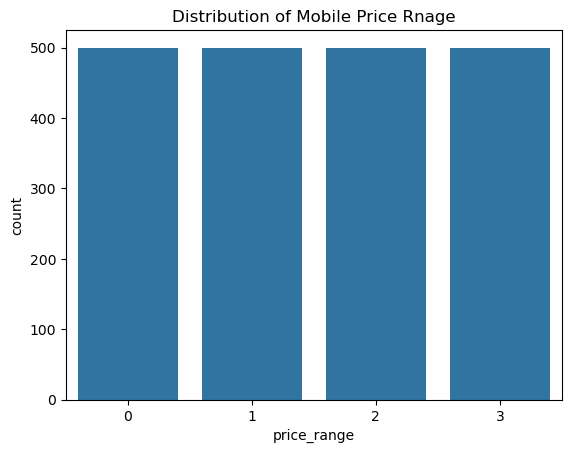

In [32]:
# Data visualization-EDA
sns.countplot(x="price_range", data=data)
plt.title("Distribution of Mobile Price Rnage")
plt.show()

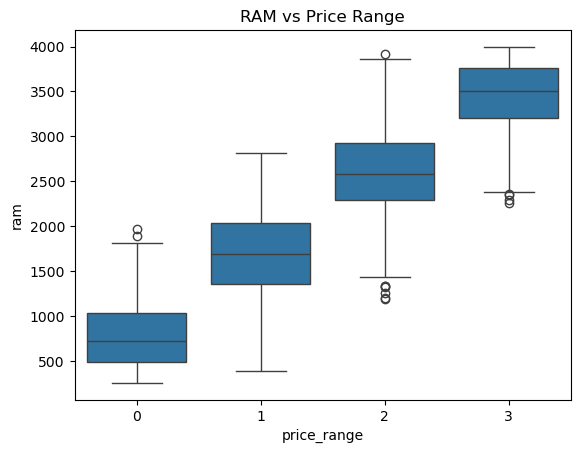

In [33]:
sns.boxplot(x="price_range", y="ram", data=data)
plt.title("RAM vs Price Range")
plt.show()

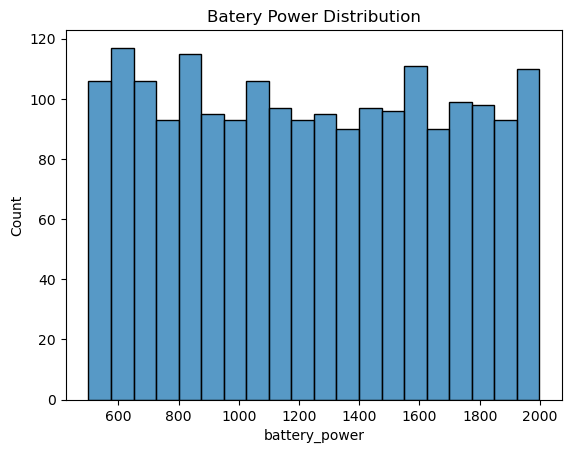

In [36]:
sns.histplot(data["battery_power"], bins=20)
plt.title("Batery Power Distribution")
plt.show()

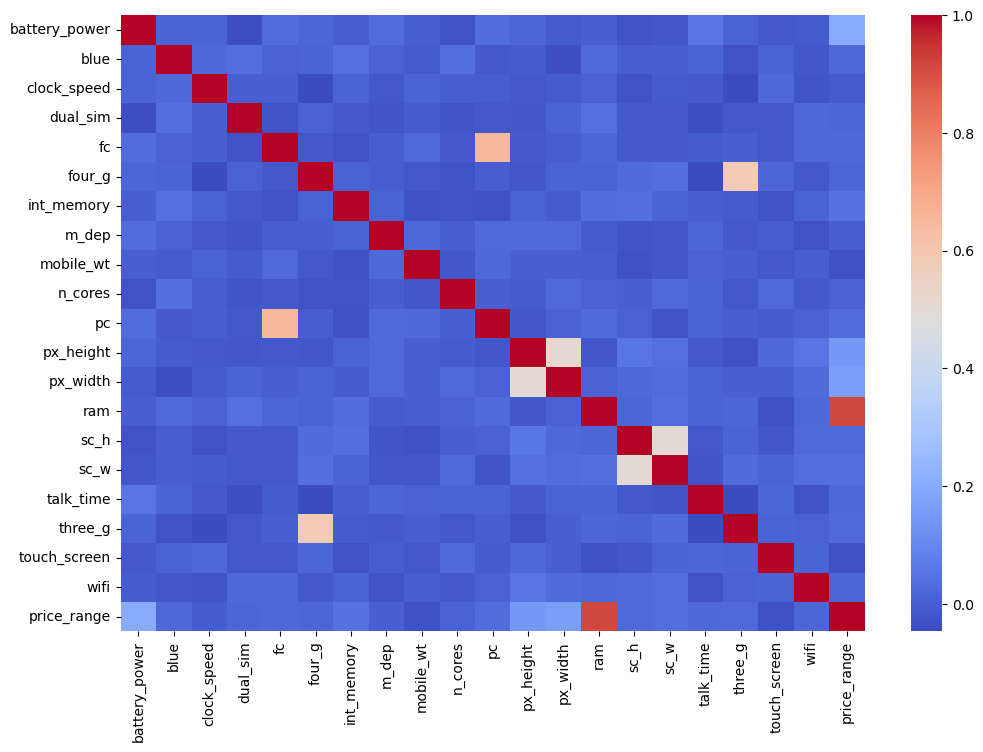

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap="coolwarm")
plt.show()

In [13]:
# Fetaure and Target split
x=data.drop("price_range", axis=1)
y=data["price_range"]

In [14]:
# Train-Test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [15]:
# Scaling the Data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [16]:
# Choosing and Training the model with prediction
from sklearn.linear_model import LogisticRegression 
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train,y_train)
lr_pred=lr.predict(x_test)

In [17]:
#Decision Tree model
from sklearn.tree import DecisionTreeClassifier
dt =  DecisionTreeClassifier()
dt.fit(x_train,y_train)
dt_pred=dt.predict(x_test)

In [18]:
#Random Forest Classifier model
from sklearn.ensemble import RandomForestClassifier
rf =  RandomForestClassifier()
rf.fit(x_train,y_train)
rf_pred = rf.predict(x_test)

In [20]:
#Model Evaluation with metrics
from sklearn.metrics import accuracy_score
lr_accuracy = accuracy_score(y_test, lr_pred)
dt_accuracy = accuracy_score(y_test, dt_pred)
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Logistic Regression Model Accuracy:", lr_accuracy)
print("Decision Tree Model Accuracy:", dt_accuracy)
print("Random Forest Classifier Model Accuracy:", rf_accuracy)

Logistic Regression Model Accuracy: 0.975
Decision Tree Model Accuracy: 0.82
Random Forest Classifier Model Accuracy: 0.905


In [21]:
print(y_train.unique())
print(y_test.unique())

[1 2 0 3]
[0 2 1 3]


In [22]:
print(lr_pred[:20])
print(dt_pred[:20])
print(rf_pred[:20])

[0 2 1 3 1 1 2 0 3 1 0 1 2 3 3 2 3 3 1 0]
[0 2 1 3 1 1 2 0 2 1 0 1 1 3 2 2 3 3 1 0]
[0 2 1 3 1 2 2 0 3 1 0 1 2 3 2 2 3 3 1 0]


In [23]:
print(x.columns)


Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi'],
      dtype='object')


In [27]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, lr_pred)
print(cm)


[[101   4   0   0]
 [  0  91   0   0]
 [  0   2  87   3]
 [  0   0   1 111]]


In [28]:
#Classification report
from sklearn.metrics import classification_report
cr = classification_report(y_test, lr_pred)
print(cr)

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       105
           1       0.94      1.00      0.97        91
           2       0.99      0.95      0.97        92
           3       0.97      0.99      0.98       112

    accuracy                           0.97       400
   macro avg       0.98      0.97      0.97       400
weighted avg       0.98      0.97      0.98       400



In [29]:
# Model comparision table
import pandas as pd
models = ["Logsitic Regression", "Decision Tree", "Random Forest"]
accuracies = [0.975, 0.82, 0.905]
comparision = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracies
})
print(comparision)

                 Model  Accuracy
0  Logsitic Regression     0.975
1        Decision Tree     0.820
2        Random Forest     0.905


In [47]:
#Feature Importance 
import pandas as pd
importance = rf.feature_importances_
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": importance
})
feature_importance=feature_importance.sort_values(by="Importance", ascending=False)
print(feature_importance)
    

          Feature  Importance
13            ram    0.464861
0   battery_power    0.074716
12       px_width    0.057641
11      px_height    0.055880
8       mobile_wt    0.041727
6      int_memory    0.038943
16      talk_time    0.031515
10             pc    0.031145
14           sc_h    0.028272
7           m_dep    0.027945
2     clock_speed    0.027918
15           sc_w    0.027911
4              fc    0.025972
9         n_cores    0.024242
5          four_g    0.007277
18   touch_screen    0.007189
1            blue    0.007049
19           wifi    0.007031
3        dual_sim    0.006704
17        three_g    0.006063


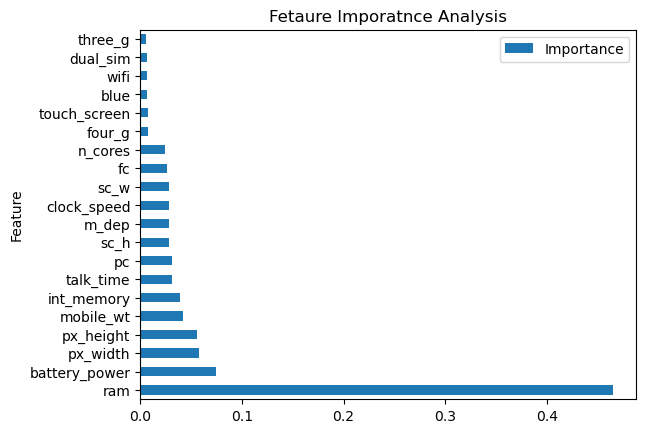

In [45]:
#Feature Importance Graph
import matplotlib.pyplot as plt
feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="barh"
)
plt.title("Fetaure Imporatnce Analysis")
plt.show()

In [ ]:
##TASK-1:Prepare a complete data analysis report on the given data.


#Exploratory Data Analysis (EDA) was performed to understand the dataset. 
#The dataset contains various mobile specifications such as battery power, RAM, pixel resolution, and connectivity features. 
#Data types and missing values were checked to ensure data quality. Visualizations were used to analyze the distribution of price ranges and the relationship between features like RAM and battery power with mobile price categories.

In [ ]:
## TASK-2: On the basis of the mobile Specification like Battery power, 3G enabled , wifi ,Bluetooth, Ram etc predict the Price range of the mobile.


# A machine learning model was developed to predict the price range of mobile phones based on specifications such as battery power, RAM, WiFi, Bluetooth, and other hardware features. 
# Multiple models including Logistic Regression, Decision Tree, and Random Forest were trained and evaluated.
# Logistic Regression achieved the highest accuracy of approximately 97%, making it the best model for predicting mobile phone price range in this dataset.

In [ ]:
## TASK-3: Prepare the analysis report stating how model will help expanding the business by stating several factors including feature importance.


# The machine learning model successfully predicts mobile phone price range using device specifications. 
# Feature importance analysis highlights that RAM, battery power, and display resolution are the most influential factors affecting price classification. 
# These insights can assist businesses in product design, pricing strategies, and market segmentation, ultimately helping companies expand their product portfolio and target appropriate customer segments.

In [ ]:
# Model Comparison Report:
# In this project, multiple machine learning models were trained to predict the price range of mobile phones based on various specifications such as RAM, battery power, screen resolution, and connectivity features. The models used include Logistic Regression, Decision Tree, and Random Forest.

# The performance of these models was evaluated using accuracy score. Logistic Regression achieved the highest accuracy of 97.5%, indicating excellent predictive capability for this dataset. Random Forest achieved an accuracy of 90.5%, while Decision Tree achieved 82% accuracy.

# The confusion matrix and classification report further confirmed that the Logistic Regression model performs consistently well across all price categories with high precision and recall values.

# Based on the evaluation results, Logistic Regression is recommended as the best model for production deployment because it provides the highest accuracy while maintaining a relatively simple and efficient model structure.

In [ ]:
##Report on Challenges Faced
# 1. Data Understanding and Exploration

#Challenge:
At the beginning of the project, understanding the dataset structure and identifying relevant features was challenging because the dataset contained multiple mobile specifications such as RAM, battery power, screen resolution, connectivity options, and memory size.

#Technique Used:
Exploratory Data Analysis (EDA) was performed using Python libraries such as Pandas, Matplotlib, and Seaborn to examine the dataset structure, data types, and statistical distribution of features.

#Reason:
EDA helps in understanding the dataset and identifying patterns or relationships between features and the target variable.

In [ ]:
#2. Model Convergence Issue

#Challenge:
While training the Logistic Regression model, a convergence warning appeared indicating that the algorithm had reached the maximum number of iterations without converging.

#Technique Used:
The parameter max_iter was increased and feature scaling was applied using StandardScaler.

#Reason:
Scaling the data ensures that all features are on a similar numerical scale, which helps optimization algorithms converge faster and improves model performance.

In [ ]:
#4. Model Selection

#Challenge:
Selecting the most suitable model for predicting mobile price range required evaluating multiple algorithms.

#Technique Used:
Three models were trained and compared:
    1.Logistic Regression
    2.Decision Tree
    3.Random Forest
The models were evaluated using accuracy score, confusion matrix, and classification report.

#Reason:
Model comparison helps identify the algorithm that provides the best prediction accuracy and reliability for the datase

In [ ]:
#5. Feature Importance Interpretation

#Challenge:
Understanding which mobile specifications most strongly influence the price range was necessary for business insights.

#Technique Used:
Feature importance analysis was performed using the Random Forest model.

#Reason:
Random Forest provides a built-in feature importance metric that helps identify the most influential features affecting the target variable.


In [ ]:
##These challenges were addressed through data preprocessing, feature scaling, and model evaluation techniques, which helped improve model performance and produce accurate predictions.

In [ ]:
## Future scope of the project:
# In the future, the model can be improved by using larger datasets with more mobile specifications such as processor type, camera quality, and brand information. 
# More data will help the model learn better patterns and improve prediction accuracy. 
# Additionally, further analysis can be performed to better understand how different mobile specifications influence price categories and help companies design more competitive products.